In [1]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image

In [2]:
class NTIREDataset(Dataset):
    def __init__(self, hf_dataset):
        """
        :param hf_dataset: A Hugging Face 'Dataset' object
                          that has been flattened such that
                          each sample is {'image': PIL.Image, 'label': 0}.
                          We assume pairs are consecutive.
        """
        self.dataset = hf_dataset
        self.transform = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor(),
        ])
        
    def __len__(self):
        return len(self.dataset) // 2
    
    def __getitem__(self, idx):
        """
        We assume train_ds[2*idx] is the 'Input' image
        and train_ds[2*idx+1] is the 'GT' image.
        """
        input_sample = self.dataset[2 * idx + 1]
        input_image = input_sample["image"]
        
        gt_sample = self.dataset[2 * idx] 
        gt_image = gt_sample["image"]

        if isinstance(input_image, Image.Image):
            input_image = self.transform(input_image)
        if isinstance(gt_image, Image.Image):
            gt_image = self.transform(gt_image)

        return input_image, gt_image

In [3]:
dataset = load_dataset(
    "okhater/NTIRE_LLE_2025", 
    name="default",
    )
print(dataset)
train_ds = dataset["train"]
validation_ds = dataset["validation"]
test_ds = dataset["test"]

print("Number of training examples:", len(train_ds))
print("Number of validation examples:", len(validation_ds))
print("Number of test examples:", len(test_ds))

Resolving data files:   0%|          | 0/438 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/46 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/438 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/46 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 438
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 46
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 30
    })
})
Number of training examples: 438
Number of validation examples: 46
Number of test examples: 30


In [4]:
sample0, sample1 = train_ds[0], train_ds[1]
print(f"Sample 0 keys: {sample0.keys()}, sample 1 keys: {sample1.keys()}")
print(f"Sample 0 value: {sample0.values()}, sample 1 value: {sample1.values()}")

Sample 0 keys: dict_keys(['image', 'label']), sample 1 keys: dict_keys(['image', 'label'])
Sample 0 value: dict_values([<PIL.PngImagePlugin.PngImageFile image mode=RGB size=2992x2000 at 0x2396FE62EA0>, 0]), sample 1 value: dict_values([<PIL.PngImagePlugin.PngImageFile image mode=RGB size=2992x2000 at 0x2397E159970>, 0])


In [5]:
print(sample0, sample1)

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=2992x2000 at 0x2396FE62EA0>, 'label': 0} {'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=2992x2000 at 0x2397E159970>, 'label': 0}


In [6]:
labels = {}
for idx, sample in enumerate(train_ds):
    label = sample["label"]
    if label not in labels:
        labels[label] = [idx]
    else:
        labels[label].append(idx)
        
print("Label counts:", labels)

Label counts: {0: [0, 1], 1: [2, 3], 2: [4, 5], 3: [6, 7], 4: [8, 9], 5: [10, 11], 6: [12, 13], 7: [14, 15], 8: [16, 17], 9: [18, 19], 10: [20, 21], 11: [22, 23], 12: [24, 25], 13: [26, 27], 14: [28, 29], 15: [30, 31], 16: [32, 33], 17: [34, 35], 18: [36, 37], 19: [38, 39], 20: [40, 41], 21: [42, 43], 22: [44, 45], 23: [46, 47], 24: [48, 49], 25: [50, 51], 26: [52, 53], 27: [54, 55], 28: [56, 57], 29: [58, 59], 30: [60, 61], 31: [62, 63], 32: [64, 65], 33: [66, 67], 34: [68, 69], 35: [70, 71], 36: [72, 73], 37: [74, 75], 38: [76, 77], 39: [78, 79], 40: [80, 81], 41: [82, 83], 42: [84, 85], 43: [86, 87], 44: [88, 89], 45: [90, 91], 46: [92, 93], 47: [94, 95], 48: [96, 97], 49: [98, 99], 50: [100, 101], 51: [102, 103], 52: [104, 105], 53: [106, 107], 54: [108, 109], 55: [110, 111], 56: [112, 113], 57: [114, 115], 58: [116, 117], 59: [118, 119], 60: [120, 121], 61: [122, 123], 62: [124, 125], 63: [126, 127], 64: [128, 129], 65: [130, 131], 66: [132, 133], 67: [134, 135], 68: [136, 137], 6

In [7]:
sample = validation_ds[45]
print("Sample keys:", sample.keys())
print("Sample content:", sample)

Sample keys: dict_keys(['image', 'label'])
Sample content: {'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=2992x2000 at 0x2397E12BA40>, 'label': 45}


In [8]:
train_loader = DataLoader(NTIREDataset(train_ds), batch_size=32, shuffle=True)
validation_loader = DataLoader(NTIREDataset(validation_ds), batch_size=32)
test_loader = DataLoader(NTIREDataset(test_ds), batch_size=32, shuffle=False)

for x, y in train_loader:
    print("x batch shape:", x.shape)  # Expected: [32, 3, 256, 256]
    if isinstance(y, torch.Tensor):
        print("y batch shape:", y.shape)
    else:
        print("y batch is a list:", len(y))
    break  


x batch shape: torch.Size([32, 3, 256, 256])
y batch shape: torch.Size([32, 3, 256, 256])


In [9]:
def show_samples(x, y, num_samples=4):
    fig, axs = plt.subplots(2, num_samples, figsize=(num_samples*3, 6))
    for i in range(num_samples):
        # x image
        axs[0, i].imshow(x[i].permute(1, 2, 0))  # Convert to HxWxC format
        axs[0, i].axis('off')
        axs[0, i].set_title("Input")
        
        # y image (label)
        axs[1, i].imshow(y[i].permute(1, 2, 0))
        axs[1, i].axis('off')
        axs[1, i].set_title("Label")
    plt.tight_layout()
    plt.show()


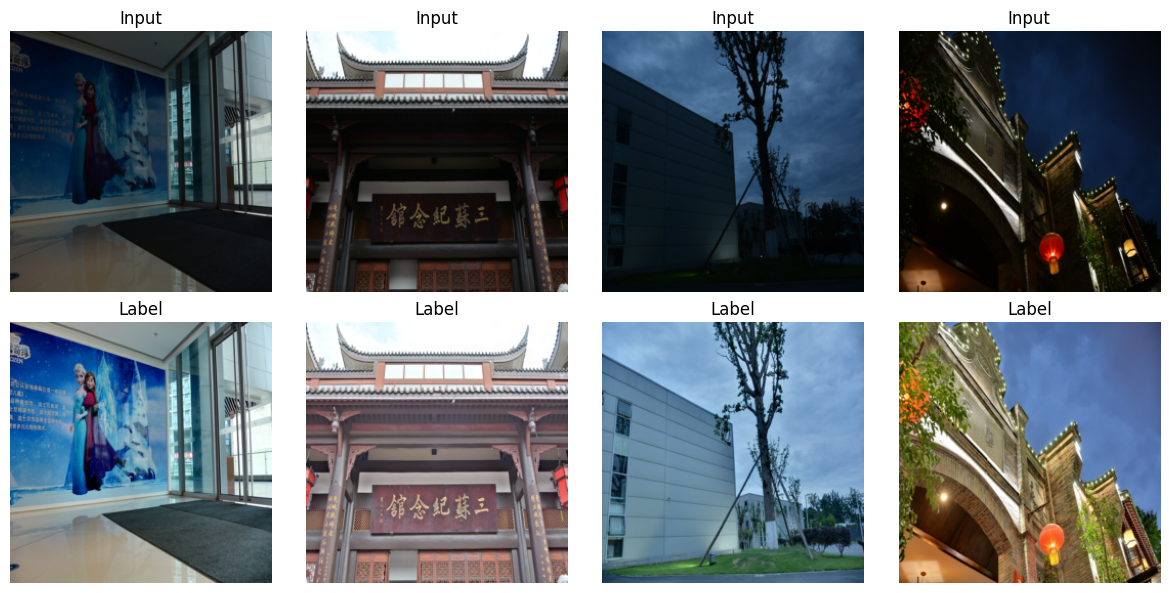

In [10]:
# Get one batch (x and y images)
x, y = next(iter(train_loader))
show_samples(x, y, num_samples=4)